Muhammad Ziyam | ERP ID: 28359 | Supply Chain Analytics (MGT-353) | Instructor: Faisal Jalal
Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Nestle Pakistan's disclosed scale, not actual company records.

SHA-256 (first 16): 5bdda4d12a2008f0 (frozen file begins 5bdda4d12a2008f0)
rows: 104 | strictly increasing: True | duplicates: 0 | gap days: {7} | all Mondays: True
nulls (excluding Exceptional_Event): 0 | demand > 0: True | distinct prices: 17
promo share: 0.192 | event weeks: 8 | stockout weeks: 8 | event&promo overlap: 2

TRAIN  : 2024-01-01 to 2025-09-29 (92 weeks)
HOLDOUT: 2025-10-06 to 2025-12-22 (12 weeks)
overlap between train and holdout dates: False
DESCRIPTIVE STATISTICS (packs per week)
Mean                           822,496.15
Median                         814,300.00
Std dev                        143,438.46
Min                            432,900.00
Max                          1,274,500.00
Range                          8

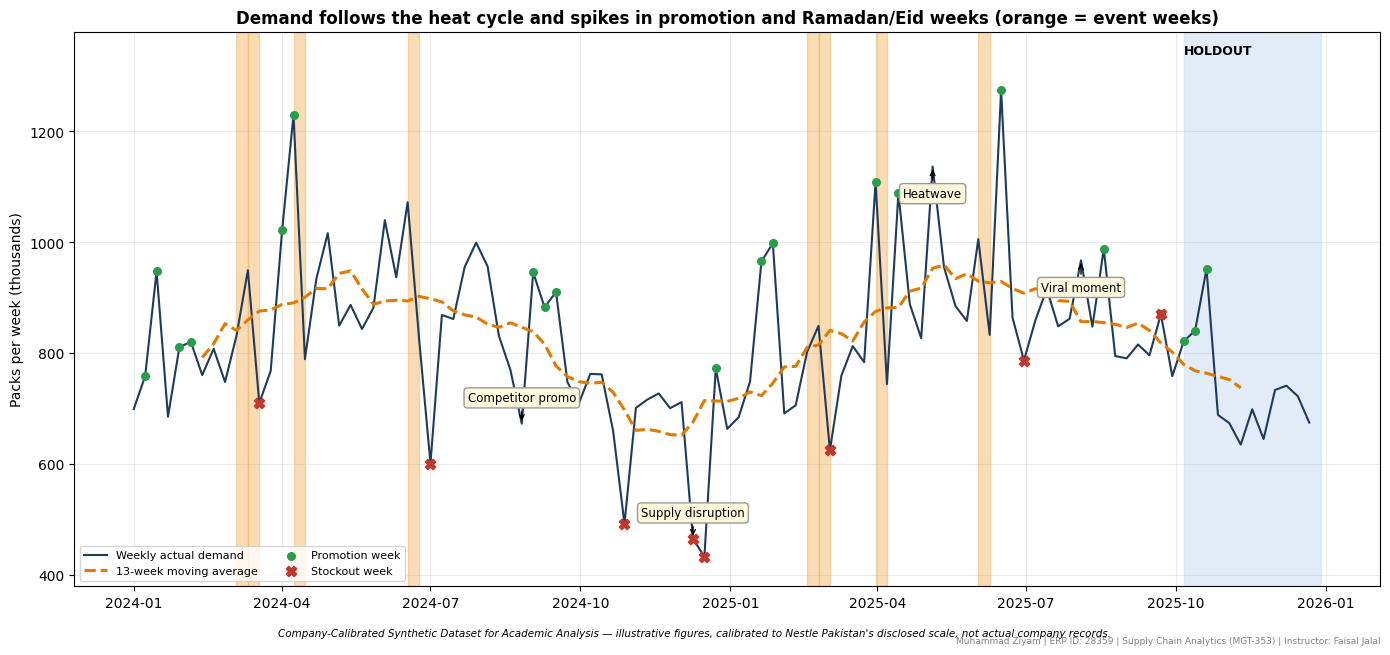

Course worked example -> {'MAD': np.float64(102.5), 'Bias': np.float64(102.5), 'RSFE': np.float64(820.0), 'Tracking Signal': np.float64(8.0)}
HISTORICAL (planner) FORECAST over all 104 weeks (not a holdout)
--- Planner Historical_Forecast, 104 weeks ---
MAD 99,421 packs: the typical weekly miss, in original units.
MAPE 13.0%: the average percentage miss (valid because demand is never near zero).
RMSE 124,328 packs: 1.25 x MAD; the higher this ratio, the more large misses dominate.
WAPE 12.1%: total absolute error relative to total volume.
Bias -52,613 packs/week: the forecast over-forecasts on average (Error = Actual - Forecast).
RSFE -5,471,800 packs: accumulated signed error.
Tracking Signal -55.0: OUTSIDE the usual +/-4 band: persistent drift, investigate.

MODEL COMPARISON ON THE SAME 12-WEEK HOLDOUT (fitted on weeks 1-92 only)
                                   MAD  MAPE %       RMSE  WAPE %       Bias        RSFE  Tracking Signal  Bias % of demand
Regression (planned inputs)  46,

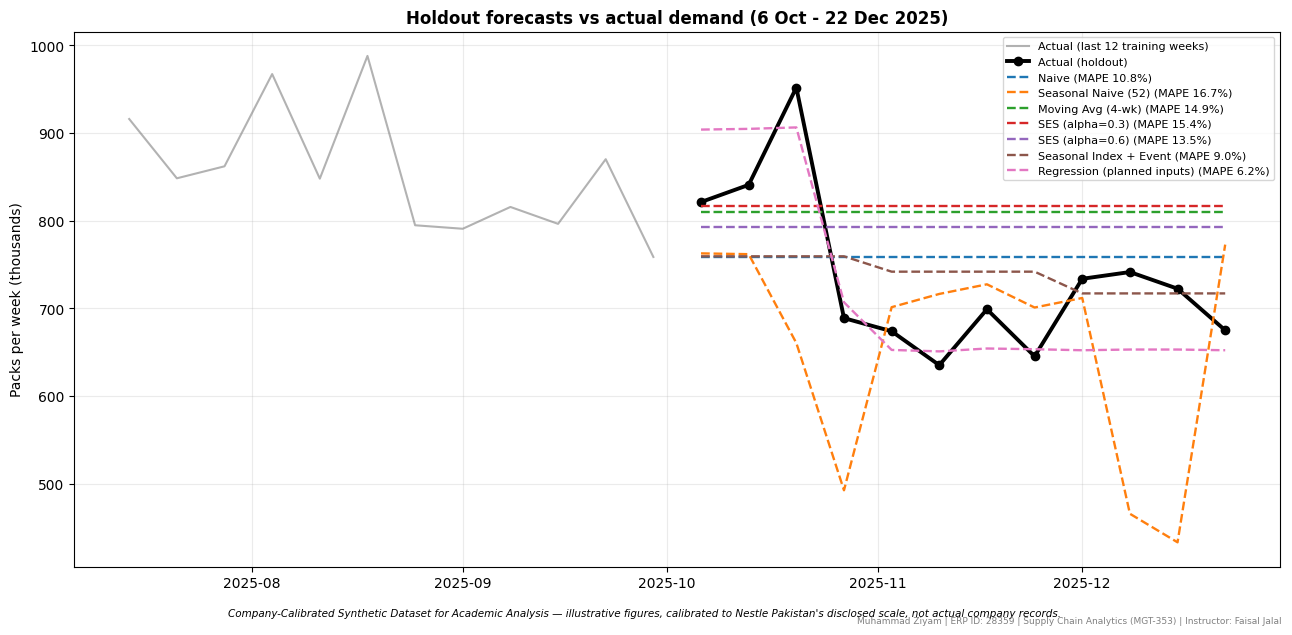


===== MODEL 1: Price, Promo_Flag, Event_Flag, Temperature =====
             Coefficient    Std Err  p-value     CI low    CI high
const         420,402.28 142,017.05     0.00 138,128.02 702,676.55
Price          -1,417.67   1,922.33     0.46  -5,238.52   2,403.18
Promo_Flag    206,636.68  21,832.01     0.00 163,243.20 250,030.16
Event_Flag    102,314.11  29,708.83     0.00  43,264.60 161,363.63
Temperature    18,095.77   1,557.86     0.00  14,999.35  21,192.19
R-squared 0.715 | Adjusted R-squared 0.702 | n = 92

===== MODEL 2: + Stockout_Flag (recommended) =====
               Coefficient    Std Err  p-value      CI low     CI high
const           419,479.91 109,936.86     0.00  200,932.66  638,027.16
Price              -821.80   1,490.11     0.58   -3,784.05    2,140.44
Promo_Flag      198,764.72  16,931.32     0.00  165,106.36  232,423.07
Event_Flag       88,576.19  23,067.13     0.00   42,720.26  134,432.11
Temperature      17,145.15   1,212.27     0.00   14,735.24   19,555.07
Sto

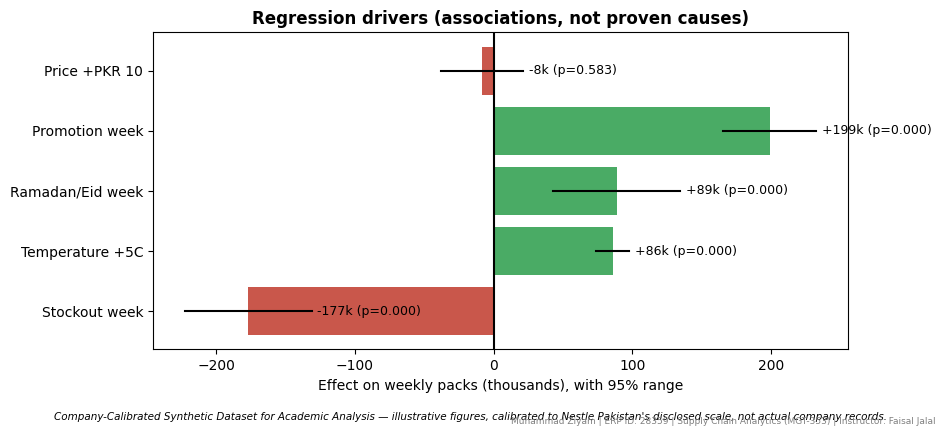

LEAKAGE TEST: max change in forecast after corrupting holdout demand/temperature/stockout values
{'Naive': 0.0, 'Seasonal Naive (52)': 0.0, 'Moving Avg (4-wk)': 0.0, 'SES (alpha=0.3)': 0.0, 'SES (alpha=0.6)': 0.0, 'Seasonal Index + Event': 0.0, 'Regression (planned inputs)': 0.0}
Zero change for every model => no model uses holdout actuals. No recursive forecasting is used (direct multi-step from one origin).

Regression MAPE as published 6.2% | if the promo schedule were unknown 9.0% | Seasonal Index + Event 9.0%
=> the regression wins mainly because it knows the planned promotion calendar (fair only if promotions are planned ahead).

FIVE LARGEST MISSES (Error = Actual - Forecast; positive = under-forecast)
Week_Start_Date  Actual_Demand   Forecast      Error    Pct  Promo_Flag  Promo_Depth  TempAnomaly                                                          Likely cause
     2025-12-08         741400 652,954.20  88,445.80  11.90           0            0         1.40  Model weakness

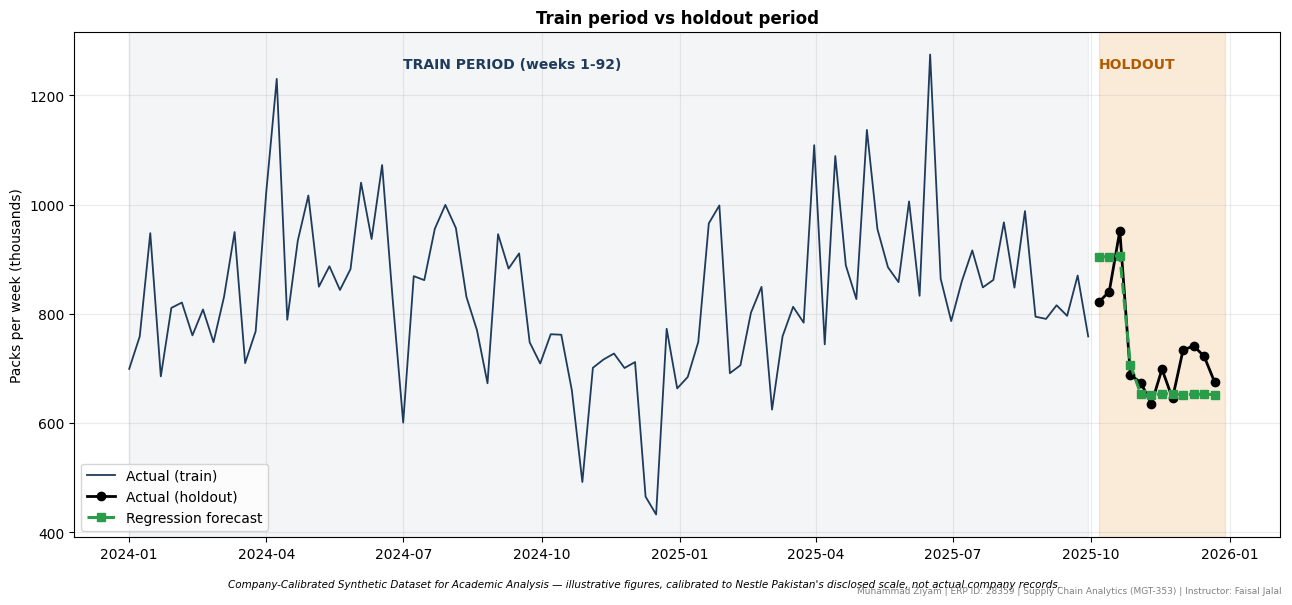

BASE FORECAST: 9.38M packs over 12 weeks (about 782,062 a week). Model-noise range P10-P90: 9.09-9.65M
Driver sensitivity: temp -2C 8.98M | temp +2C 9.79M | no promos 9.00M | 4 promos 9.77M -> realistic range about 8.9-9.8M
Plausibility: same 12 weeks one year earlier = 9.31M (x1.03 growth = 9.59M)

TOTAL COST BY SCENARIO AND POLICY (PKR million: lost margin + carrying + flex premium + write-off risk)
policy                                     A: Commit 100%  B: Commit 85% + flex  C: Over-commit 110%  D: Lean 70% + heavy flex  E: Commit 100% + 1wk buffer
scenario                                                                                                                                                   
Base                                                 2.11                  4.42                 2.64                      8.21                         4.45
Demand -10%                                          3.30                  3.78                 6.52                      6.43 

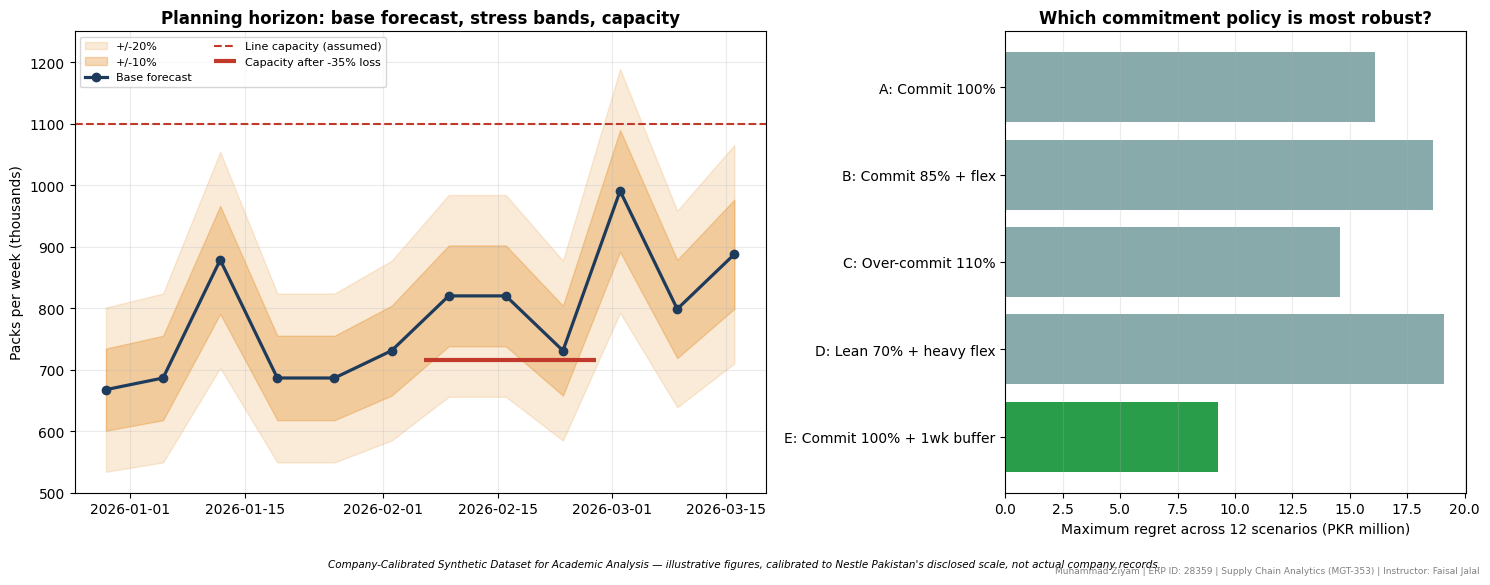

Muhammad Ziyam | ERP ID: 28359 | Supply Chain Analytics (MGT-353) | Instructor: Faisal Jalal
Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Nestle Pakistan's disclosed scale, not actual company records. 

FORECAST (expected demand, not a sales target): 9.38M packs, 29 Dec 2025 - 22 Mar 2026 (model-noise range 9.09-9.65M; realistic range about 8.9-9.8M)
BEST MODEL: Regression, holdout MAPE 6.2%, WAPE 6.4%, MAD 46,868, bias +15,436 packs/week, tracking signal +4.0 (Error = Actual - Forecast)
RECOMMENDED OPERATIONAL PLAN (Policy E): commit firm orders to 100% of the forecast, hold about 1,173,093 packs (1.5 weeks) of opening stock,
  keep flexible supply for up to 10% of weekly volume. Smallest worst-case regret: PKR 9.3m vs 14.6m for the next best policy.
REVIEW TRIGGERS: first two weeks outside +/-10% of forecast (1,218,706 to 1,489,529 packs) | tracking signal outside +/-4 | four-week demand >10% off forecast |
  packaging delivery slip

In [2]:
# # Supply Chain Analytics Portfolio, Milestone 1: Analysis Notebook
# **Student:** Muhammad Ziyam  |  **ERP ID:** 28359
# **Course:** Supply Chain Analytics (MGT-353)  |  **Instructor:** Faisal Jalal
# **Company / product:** Nestlé Pakistan, Fruita Vitals 200ml (weekly packs)
#
# *Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Nestle Pakistan's disclosed scale, not actual company records.*
#
# **Decision:** How many Fruita Vitals 200ml packs should we plan to supply over the next 12 weeks (29 Dec 2025 – 22 Mar 2026), and how much should we commit now versus keep flexible?
#
# **How to run:** Runtime ▸ Run all. When asked, upload `fruita_vitals_200ml_weekly_synthetic.csv`.
# **Error convention used everywhere:** Error = Actual − Forecast. Positive bias / tracking signal = under-forecast; negative = over-forecast.
#
# **Contents:** 1 Setup and data checks · 2 Demand profile · 3 Error metrics · 4 Models and comparison · 5 Regression · 6 Holdout validation · 7 Stress test · 8 Summary

# %%
# ===== 1. SETUP, DATA LOAD AND INTEGRITY CHECKS =====
import os, hashlib, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

LABEL = ("Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, "
         "calibrated to Nestle Pakistan's disclosed scale, not actual company records.")
STUDENT = "Muhammad Ziyam | ERP ID: 28359 | Supply Chain Analytics (MGT-353) | Instructor: Faisal Jalal"
def stamp(fig):
    fig.text(0.5, 0.012, LABEL, ha="center", fontsize=7.5, style="italic")
    fig.text(0.99, 0.002, STUDENT, ha="right", fontsize=6.5, color="grey")
print(STUDENT); print(LABEL)

CSV = "fruita_vitals_200ml_weekly_synthetic.csv"
if not os.path.exists(CSV):
    try:
        from google.colab import files
        print("Please upload", CSV); files.upload()
    except ImportError:
        raise FileNotFoundError(f"Put {CSV} in the working folder")
raw = open(CSV, "rb").read()
df = pd.read_csv(CSV, parse_dates=["Week_Start_Date"])
print("\nSHA-256 (first 16):", hashlib.sha256(raw).hexdigest()[:16], "(frozen file begins 5bdda4d12a2008f0)")

# ---- date and data integrity
d = df.Week_Start_Date
print("rows:", len(df), "| strictly increasing:", d.is_monotonic_increasing, "| duplicates:", int(d.duplicated().sum()),
      "| gap days:", set(d.diff().dropna().dt.days), "| all Mondays:", set(d.dt.dayofweek) == {0})
print("nulls (excluding Exceptional_Event):", int(df.drop(columns="Exceptional_Event").isna().sum().sum()),
      "| demand > 0:", bool((df.Actual_Demand > 0).all()), "| distinct prices:", df.Price.nunique())
print("promo share:", round(df.Promo_Flag.mean(), 3), "| event weeks:", int(df.Event_Flag.sum()),
      "| stockout weeks:", int(df.Stockout_Flag.sum()), "| event&promo overlap:", int(((df.Event_Flag == 1) & (df.Promo_Flag == 1)).sum()))

# ---- train / holdout split (final 12 weeks held out)
H = 12
train_df, test_df = df.iloc[:-H].copy(), df.iloc[-H:].copy()
print(f"\nTRAIN  : {train_df.Week_Start_Date.min().date()} to {train_df.Week_Start_Date.max().date()} ({len(train_df)} weeks)")
print(f"HOLDOUT: {test_df.Week_Start_Date.min().date()} to {test_df.Week_Start_Date.max().date()} ({len(test_df)} weeks)")
print("overlap between train and holdout dates:", bool(set(train_df.Week_Start_Date) & set(test_df.Week_Start_Date)))
df.head()

# %%
# ===== 2. DEMAND PROFILE: WHAT HAPPENED? =====
y = df.Actual_Demand
stats = pd.Series({"Mean": y.mean(), "Median": y.median(), "Std dev": y.std(), "Min": y.min(), "Max": y.max(),
                   "Range": y.max() - y.min(), "Coefficient of variation %": 100 * y.std() / y.mean()})
print("DESCRIPTIVE STATISTICS (packs per week)"); print(stats.to_string())

ann = df.groupby(df.Week_Start_Date.dt.year).Actual_Demand.mean()
mon = df.groupby(df.Week_Start_Date.dt.month).Actual_Demand.mean()
print(f"\nTREND: annual average {ann.iloc[0]:,.0f} -> {ann.iloc[1]:,.0f} ({100*(ann.iloc[1]/ann.iloc[0]-1):+.1f}%)")
print(f"SEASONALITY: June average {mon[6]:,.0f} vs December average {mon[12]:,.0f}")
print("\nAVERAGE DEMAND BY CONDITION")
print(pd.DataFrame({"Promo weeks": [df[df.Promo_Flag == 1].Actual_Demand.mean()], "Non-promo": [df[df.Promo_Flag == 0].Actual_Demand.mean()],
                    "Event weeks": [df[df.Event_Flag == 1].Actual_Demand.mean()], "Non-event": [df[df.Event_Flag == 0].Actual_Demand.mean()],
                    "Stockout weeks": [df[df.Stockout_Flag == 1].Actual_Demand.mean()], "No stockout": [df[df.Stockout_Flag == 0].Actual_Demand.mean()]}).T.rename(columns={0: "Avg packs/week"}))

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(df.Week_Start_Date, y/1000, color="#1f3b5c", lw=1.5, label="Weekly actual demand")
ax.plot(df.Week_Start_Date, (y.rolling(13, center=True).mean())/1000, "--", color="#e07b00", lw=2.2, label="13-week moving average")
p = df[df.Promo_Flag == 1]; s = df[df.Stockout_Flag == 1]
ax.scatter(p.Week_Start_Date, p.Actual_Demand/1000, color="#2a9d4a", s=30, zorder=3, label="Promotion week")
ax.scatter(s.Week_Start_Date, s.Actual_Demand/1000, color="#c0392b", marker="X", s=55, zorder=4, label="Stockout week")
for _, r in df[df.Event_Flag == 1].iterrows(): ax.axvspan(r.Week_Start_Date, r.Week_Start_Date + pd.Timedelta(days=7), color="#f2b25c", alpha=.45)
ax.axvspan(test_df.Week_Start_Date.min(), test_df.Week_Start_Date.max() + pd.Timedelta(days=7), color="#cfe0f5", alpha=.6)
ax.text(test_df.Week_Start_Date.min(), 1340, "HOLDOUT", fontsize=9, fontweight="bold")
for i, t in ((34, "Competitor promo"), (49, "Supply disruption"), (70, "Heatwave"), (83, "Viral moment")):
    ax.annotate(t, (df.Week_Start_Date[i], y[i]/1000), xytext=(0, -22 if y[i] > 700000 else 16), textcoords="offset points", ha="center", fontsize=8.5,
                arrowprops=dict(arrowstyle="->"), bbox=dict(boxstyle="round", fc="#fff8dc", ec="#999"))
ax.set_ylim(380, 1380); ax.set_ylabel("Packs per week (thousands)"); ax.grid(alpha=.25); ax.legend(loc="lower left", ncol=2, fontsize=8)
ax.set_title("Demand follows the heat cycle and spikes in promotion and Ramadan/Eid weeks (orange = event weeks)", fontweight="bold")
stamp(fig); fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

# %%
# ===== 3. FORECAST ERROR METRICS (Error = Actual - Forecast) =====
def metrics(a, f):
    a = np.asarray(a, float); f = np.asarray(f, float); e = a - f; mad = np.abs(e).mean()
    return {"MAD": mad, "MAPE %": 100*np.mean(np.abs(e)/a), "RMSE": np.sqrt((e**2).mean()), "WAPE %": 100*np.abs(e).sum()/a.sum(),
            "Bias": e.mean(), "RSFE": e.sum(), "Tracking Signal": e.sum()/mad}

# sanity check against the course worked example (expected MAD 102.5, Bias +102.5, RSFE +820, TS 8.0)
ex = metrics([1200,1250,1610,1390,1290,1340,1520,1610], [1150,1200,1350,1300,1280,1310,1380,1420])
print("Course worked example ->", {k: round(v, 2) for k, v in ex.items() if k in ("MAD", "Bias", "RSFE", "Tracking Signal")})

def explain(m, name):
    sign = "under-forecasts" if m["Bias"] > 0 else "over-forecasts"
    print(f"--- {name} ---")
    print(f"MAD {m['MAD']:,.0f} packs: the typical weekly miss, in original units.")
    print(f"MAPE {m['MAPE %']:.1f}%: the average percentage miss (valid because demand is never near zero).")
    print(f"RMSE {m['RMSE']:,.0f} packs: {m['RMSE']/m['MAD']:.2f} x MAD; the higher this ratio, the more large misses dominate.")
    print(f"WAPE {m['WAPE %']:.1f}%: total absolute error relative to total volume.")
    print(f"Bias {m['Bias']:,.0f} packs/week: the forecast {sign} on average (Error = Actual - Forecast).")
    print(f"RSFE {m['RSFE']:,.0f} packs: accumulated signed error.")
    flag = "OUTSIDE the usual +/-4 band: persistent drift, investigate" if abs(m["Tracking Signal"]) > 4 else "inside the usual +/-4 band"
    print(f"Tracking Signal {m['Tracking Signal']:.1f}: {flag}.\n")

planner = metrics(df.Actual_Demand, df.Historical_Forecast)
print("HISTORICAL (planner) FORECAST over all 104 weeks (not a holdout)")
explain(planner, "Planner Historical_Forecast, 104 weeks")

# %%
# ===== 4. FORECAST MODELS AND HOLDOUT COMPARISON =====
X = ["Price", "Promo_Flag", "Event_Flag", "Temperature", "Stockout_Flag"]

def ses_level(x, alpha):
    level = np.mean(x[:4])
    for v in x: level = alpha*v + (1-alpha)*level
    return level

def model_forecasts(train, test):
    """All models are fitted ONLY on `train`. `test` supplies calendar inputs (month, Event_Flag) and planned inputs
    (Price, Promo_Flag); it never supplies demand. Forecasts are direct multi-step from one origin (no recursion)."""
    y = train.Actual_Demand.values.astype(float); h = len(test); out = {}
    out["Naive"] = np.repeat(y[-1], h)
    out["Seasonal Naive (52)"] = y[len(y)-52: len(y)-52+h]
    out["Moving Avg (4-wk)"] = np.repeat(y[-4:].mean(), h)
    for a in (0.3, 0.6): out[f"SES (alpha={a})"] = np.repeat(ses_level(y, a), h)
    # Seasonal index x SES, accounting for Event_Flag. Month index uses BASELINE weeks only; the event multiplier is estimated
    # from event weeks that are NOT also promotion or stockout weeks (avoids inflating the event effect).
    mo = train.Week_Start_Date.dt.month.values; ev = train.Event_Flag.values == 1
    base = (~ev) & (train.Promo_Flag.values == 0) & (train.Stockout_Flag.values == 0)
    mm = pd.Series(y[base]).groupby(mo[base]).mean(); si = (mm/mm.mean()).reindex(range(1, 13)).fillna(1.0)
    des = y / si.loc[mo].values
    clean_ev = ev & (train.Promo_Flag.values == 0) & (train.Stockout_Flag.values == 0)
    evm = des[clean_ev].mean() / des[base].mean() if clean_ev.any() else 1.0
    level = ses_level(np.where(ev, des/evm, des), 0.3)
    out["Seasonal Index + Event"] = level * si.loc[test.Week_Start_Date.dt.month.values].values * np.where(test.Event_Flag.values == 1, evm, 1.0)
    # Regression with planned inputs: planned Price and Promo_Flag, calendar Event_Flag, seasonal-normal Temperature, no stockout
    reg = sm.OLS(train.Actual_Demand, sm.add_constant(train[X])).fit()
    clim = train.groupby(train.Week_Start_Date.dt.month).Temperature.mean()
    fut = test[X].copy(); fut["Temperature"] = clim.reindex(test.Week_Start_Date.dt.month.values).fillna(train.Temperature.mean()).values; fut["Stockout_Flag"] = 0
    out["Regression (planned inputs)"] = reg.predict(sm.add_constant(fut, has_constant="add")).values
    return out

actual = test_df.Actual_Demand.values.astype(float)
fc = model_forecasts(train_df, test_df)
res = pd.DataFrame({k: metrics(actual, v) for k, v in fc.items()}).T
res["Bias % of demand"] = 100 * res["RSFE"] / actual.sum()
print("MODEL COMPARISON ON THE SAME 12-WEEK HOLDOUT (fitted on weeks 1-92 only)")
print(res.sort_values("MAD").round(1).to_string())

best = res["MAD"].min()
screen = pd.DataFrame({"MAD vs best %": 100*(res["MAD"]/best - 1), "Bias OK (|bias|<=5%)": res["Bias % of demand"].abs() <= 5,
                       "Tracking OK (|TS|<=4)": res["Tracking Signal"].abs() <= 4, "Beats Naive": res["MAD"] < res.loc["Naive", "MAD"]})
print("\nMODEL-SELECTION SCREEN (do not pick a winner just because it is sophisticated)"); print(screen.round(1).to_string())
for k in ("Regression (planned inputs)", "Seasonal Index + Event", "Naive"): explain(res.loc[k].to_dict(), k + " (holdout)")

fig, ax = plt.subplots(figsize=(13, 6.3))
ax.plot(train_df.Week_Start_Date.iloc[-12:], train_df.Actual_Demand.iloc[-12:]/1000, color="grey", alpha=.6, label="Actual (last 12 training weeks)")
ax.plot(test_df.Week_Start_Date, actual/1000, "o-", color="black", lw=2.8, label="Actual (holdout)")
for k, v in fc.items(): ax.plot(test_df.Week_Start_Date, v/1000, "--", lw=1.7, label=f"{k} (MAPE {res.loc[k, 'MAPE %']:.1f}%)")
ax.set_ylabel("Packs per week (thousands)"); ax.grid(alpha=.25); ax.legend(fontsize=8, loc="upper right")
ax.set_title("Holdout forecasts vs actual demand (6 Oct - 22 Dec 2025)", fontweight="bold"); stamp(fig); fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

# %%
# ===== 5. REGRESSION: WHAT DRIVES DEMAND? (fitted on train_df only) =====
def fit(cols, data=train_df, y="Actual_Demand"):
    return sm.OLS(data[y], sm.add_constant(data[cols])).fit()
X1 = ["Price", "Promo_Flag", "Event_Flag", "Temperature"]          # the specified model
m1, m2 = fit(X1), fit(X)                                            # Model 2 adds the Stockout control
def table(m):
    return pd.DataFrame({"Coefficient": m.params, "Std Err": m.bse, "p-value": m.pvalues, "CI low": m.conf_int()[0], "CI high": m.conf_int()[1]}).round(4)
for nm, m in (("MODEL 1: Price, Promo_Flag, Event_Flag, Temperature", m1), ("MODEL 2: + Stockout_Flag (recommended)", m2)):
    print(f"\n===== {nm} =====\n{table(m).to_string()}\nR-squared {m.rsquared:.3f} | Adjusted R-squared {m.rsquared_adj:.3f} | n = {int(m.nobs)}")

print("\nPLAIN-ENGLISH MEANING (Model 2; 'associated with', holding the other variables constant)")
b = m2.params; mean_d = train_df.Actual_Demand.mean()
print(f"- Intercept {b['const']:,.0f}: model baseline when every variable is zero; outside the data range, so not interpreted.")
print(f"- Price: PKR 1 higher is associated with {b['Price']:,.0f} packs/week (p = {m2.pvalues['Price']:.2f}); the range includes zero in this model.")
print(f"- Promo_Flag: a promotion week is associated with {b['Promo_Flag']:+,.0f} packs ({100*b['Promo_Flag']/mean_d:.0f}% of average demand).")
print(f"- Event_Flag: a Ramadan/Eid week is associated with {b['Event_Flag']:+,.0f} packs ({100*b['Event_Flag']/mean_d:.0f}%).")
print(f"- Temperature: +1 degree C is associated with {b['Temperature']:+,.0f} packs ({5*b['Temperature']:+,.0f} for +5 degrees C).")
print(f"- Stockout_Flag: a stockout week is associated with {b['Stockout_Flag']:+,.0f} packs ({100*b['Stockout_Flag']/mean_d:.0f}%).")
print("Statistical significance is not managerial significance, and association is not proof of cause.")

# ---- diagnostics
Xd = sm.add_constant(train_df[X])
print("\nDIAGNOSTICS")
print("VIF:", {c: round(variance_inflation_factor(Xd.values, i+1), 2) for i, c in enumerate(X)})
print("Durbin-Watson:", round(durbin_watson(m2.resid), 2), "| Ljung-Box lag-4 p:", round(float(acorr_ljungbox(m2.resid, lags=[4])["lb_pvalue"].iloc[0]), 4),
      "| Breusch-Pagan p:", round(het_breuschpagan(m2.resid, Xd)[1], 3))
hac = m2.get_robustcov_results(cov_type="HAC", maxlags=4)
print("p-values with autocorrelation-robust (Newey-West) errors:", dict(zip(["const"] + X, np.round(hac.pvalues, 4))))
cd = m2.get_influence().cooks_distance[0]; print("Largest Cook's distance:", round(float(cd.max()), 2))

# ---- challenge the coefficients
print("\nPRICE vs TREND CONFOUNDING: corr(Price, week index) =", round(np.corrcoef(train_df.Price, np.arange(len(train_df)))[0, 1], 2))
mt = fit(X + ["Trend"], train_df.assign(Trend=np.arange(len(train_df))))
print(f"With a time trend added: Price {mt.params['Price']:,.0f} packs per PKR (p={mt.pvalues['Price']:.2f}); trend {mt.params['Trend']:,.0f} packs/week per week (p={mt.pvalues['Trend']:.2f}).")
print("=> price is mixed up with the trend, so its effect is unidentified here; test price changes deliberately.")
h1, h2 = train_df.iloc[:46], train_df.iloc[46:]
print("\nSTABILITY across halves:", pd.DataFrame({"weeks 1-46": fit(X, h1).params, "weeks 47-92": fit(X, h2).params}).drop("const").round(0).to_dict("index"))
dp = fit(["Price", "Promo_Depth", "Event_Flag", "Temperature", "Stockout_Flag"])
print(f"PROMO DEPTH model: each extra discount point is associated with {dp.params['Promo_Depth']:+,.0f} packs (R2 {dp.rsquared:.3f}) -> depth matters; Promo_Flag lumps all discounts.")
ml = sm.OLS(np.log(train_df.Actual_Demand), sm.add_constant(train_df[X])).fit()
print("LOG model % effects:", {c: round(100*(np.exp(ml.params[c])-1), 1) for c in ("Promo_Flag", "Event_Flag", "Stockout_Flag")}, "| per degree C:", round(100*(np.exp(ml.params['Temperature'])-1), 1), "%")

# ---- coefficient chart: effect of a typical swing with 95% range
swing = {"Price": (10, "Price +PKR 10"), "Promo_Flag": (1, "Promotion week"), "Event_Flag": (1, "Ramadan/Eid week"), "Temperature": (5, "Temperature +5C"), "Stockout_Flag": (1, "Stockout week")}
ci = m2.conf_int(); fig, ax = plt.subplots(figsize=(9.5, 4.3))
for i, (k, (sw, nm)) in enumerate(swing.items()):
    v = b[k]*sw/1000; lo, hi = ci.loc[k, 0]*sw/1000, ci.loc[k, 1]*sw/1000
    ax.barh(i, v, color="#2a9d4a" if v > 0 else "#c0392b", alpha=.85); ax.plot([lo, hi], [i, i], color="black")
    ax.text(max(hi, v)+4, i, f"{v:+.0f}k (p={m2.pvalues[k]:.3f})", va="center", fontsize=9)
ax.set_yticks(range(len(swing))); ax.set_yticklabels([v[1] for v in swing.values()]); ax.invert_yaxis(); ax.axvline(0, color="black")
ax.set_xlabel("Effect on weekly packs (thousands), with 95% range"); ax.set_title("Regression drivers (associations, not proven causes)", fontweight="bold")
stamp(fig); fig.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

# %%
# ===== 6. HOLDOUT VALIDATION: TRAIN -> FORECAST -> REVEAL -> MEASURE -> DIAGNOSE =====
# 6a. Leakage test: destroy every holdout value a model must not use, re-run, and compare forecasts.
d2 = df.copy(); idx = d2.index[-H:]; rng = np.random.default_rng(1)
d2.loc[idx, "Actual_Demand"] = rng.integers(1, 9_000_000, H); d2.loc[idx, "Historical_Forecast"] = rng.integers(1, 9_000_000, H)
d2.loc[idx, "Temperature"] = -50.0; d2.loc[idx, "Stockout_Flag"] = rng.integers(0, 2, H)       # Price, Promo, Event stay: they are planned inputs
fc2 = model_forecasts(d2.iloc[:-H], d2.iloc[-H:])
print("LEAKAGE TEST: max change in forecast after corrupting holdout demand/temperature/stockout values")
print({k: float(np.abs(fc[k] - fc2[k]).max()) for k in fc})
print("Zero change for every model => no model uses holdout actuals. No recursive forecasting is used (direct multi-step from one origin).")

# 6b. What does the regression's accuracy depend on?
reg_pred = fc["Regression (planned inputs)"]
nopromo = model_forecasts(train_df, test_df.assign(Promo_Flag=0))["Regression (planned inputs)"]
print(f"\nRegression MAPE as published {metrics(actual, reg_pred)['MAPE %']:.1f}% | if the promo schedule were unknown {metrics(actual, nopromo)['MAPE %']:.1f}% "
      f"| Seasonal Index + Event {res.loc['Seasonal Index + Event', 'MAPE %']:.1f}%")
print("=> the regression wins mainly because it knows the planned promotion calendar (fair only if promotions are planned ahead).")

# 6c. Five largest misses for the best model
e = actual - reg_pred; clim = train_df.groupby(train_df.Week_Start_Date.dt.month).Temperature.mean()
anom = test_df.Temperature.values - clim.loc[test_df.Week_Start_Date.dt.month.values].values
miss = test_df.assign(Forecast=reg_pred, Error=e, Pct=100*e/actual, TempAnomaly=anom)
top = miss.reindex(miss.Error.abs().sort_values(ascending=False).index).head(5)
def tag(r):
    if r.Promo_Flag == 1 and r.Error < 0: return "Promotion effect: a flat promo lift over-forecasts a shallow discount"
    if r.Promo_Flag == 1: return "Promotion effect: lift larger than the average promo"
    if r.Stockout_Flag == 1: return "Stockout / data issue"
    if r.Error > 0 and r.Week_Start_Date.month == 12: return "Model weakness in December (cause unverified; weather explains part)"
    return "Unexplained variation"
top["Likely cause"] = top.apply(tag, axis=1)
print("\nFIVE LARGEST MISSES (Error = Actual - Forecast; positive = under-forecast)")
print(top[["Week_Start_Date", "Actual_Demand", "Forecast", "Error", "Pct", "Promo_Flag", "Promo_Depth", "TempAnomaly", "Likely cause"]].round(1).to_string(index=False))
print(f"Promotion weeks are 3 of 12 holdout weeks but {100*np.abs(e)[test_df.Promo_Flag.values == 1].sum()/np.abs(e).sum():.0f}% of total absolute error.")

# 6d. Is the accuracy suspiciously good?
print(f"\nSUSPICION CHECK: weeks with |error| < 1%: {int((np.abs(e/actual) < 0.01).sum())} of {H} | correlation(forecast, actual): {np.corrcoef(reg_pred, actual)[0, 1]:.2f} "
      f"| holdout MAPE {metrics(actual, reg_pred)['MAPE %']:.1f}% vs in-sample MAPE {100*np.mean(np.abs(m2.resid/train_df.Actual_Demand)):.1f}% -> not suspiciously perfect.")

# 6e. Rolling-origin check: does the winner win only because of one lucky holdout?
rows = []
for o in range(56, len(df) - H + 1, 4):
    f_o = model_forecasts(df.iloc[:o], df.iloc[o:o+H]); a_o = df.Actual_Demand.values[o:o+H].astype(float)
    rows.append({"origin": o, **{k: metrics(a_o, f_o[k])["MAPE %"] for k in ("Regression (planned inputs)", "Seasonal Index + Event", "Naive")}})
roll = pd.DataFrame(rows).set_index("origin"); print("\nROLLING-ORIGIN CHECK: MAPE % by forecast origin (12-week horizon)"); print(roll.round(1).to_string())
print("Average:", roll.mean().round(1).to_dict(), "| regression best in", int((roll.iloc[:, 0] < roll.iloc[:, 1:].min(axis=1)).sum()), "of", len(roll), "origins")
print("Caveat: the holdout was also used to choose among models, so its accuracy is mildly optimistic; the rolling check is the supporting evidence.")

# 6f. Train / holdout chart for the dashboard
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_df.Week_Start_Date, train_df.Actual_Demand/1000, color="#1f3b5c", lw=1.3, label="Actual (train)")
ax.axvspan(train_df.Week_Start_Date.min(), train_df.Week_Start_Date.max(), color="#1f3b5c", alpha=.05)
ax.axvspan(test_df.Week_Start_Date.min(), test_df.Week_Start_Date.max() + pd.Timedelta(days=7), color="#e07b00", alpha=.15)
ax.plot(test_df.Week_Start_Date, actual/1000, "ko-", lw=2, label="Actual (holdout)"); ax.plot(test_df.Week_Start_Date, reg_pred/1000, "s--", color="#2a9d4a", lw=2.2, label="Regression forecast")
ax.text(pd.Timestamp("2024-07-01"), 1250, "TRAIN PERIOD (weeks 1-92)", fontweight="bold", color="#1f3b5c"); ax.text(test_df.Week_Start_Date.min(), 1250, "HOLDOUT", fontweight="bold", color="#b35a00")
ax.set_ylabel("Packs per week (thousands)"); ax.legend(loc="lower left"); ax.grid(alpha=.25); ax.set_title("Train period vs holdout period", fontweight="bold"); stamp(fig); fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

# %%
# ===== 7. STRESS TEST: WHAT IF WE ARE WRONG? =====
# Decision horizon: 12 weeks from 29 Dec 2025. The forecast model is refitted on ALL 104 weeks (standard practice after validation).
# ALL cost and capacity parameters below are ASSUMPTIONS for illustration, not company data.
CAP, MARGIN, COST, CARRY, FLEX_PREM, WRITEOFF, COVER = 1_100_000, 22.0, 50.0, 0.005, 3.0, 0.10, 2.0
reg_all = sm.OLS(df.Actual_Demand, sm.add_constant(df[X])).fit()
dates = pd.date_range("2025-12-29", periods=12, freq="W-MON")
clim_all = df.groupby(df.Week_Start_Date.dt.month).Temperature.mean()
def plan_inputs(promos=(2, 9), price=80.0, dtemp=0.0):
    f = pd.DataFrame({"Price": price, "Promo_Flag": 0, "Event_Flag": 0, "Temperature": clim_all.loc[dates.month].values + dtemp, "Stockout_Flag": 0}, index=range(12))
    for w in promos: f.loc[w, "Promo_Flag"] = 1                 # assumed promos: 12 Jan and 2 Mar 2026
    for w in (6, 7, 11): f.loc[w, "Event_Flag"] = 1             # pre-Ramadan 9 Feb, Ramadan start 16 Feb (19 Feb), Eid week 16 Mar (about 21 Mar)
    return f
fut = plan_inputs(); F = reg_all.predict(sm.add_constant(fut, has_constant="add")).values
promo_eff, event_eff = reg_all.params["Promo_Flag"], reg_all.params["Event_Flag"]

# uncertainty of the 12-week total: model noise (block bootstrap) and driver uncertainty (temperature, promo plan)
rng = np.random.default_rng(353); res_all = reg_all.resid.values
noise = np.array([sum(res_all[s:s+4].sum() for s in rng.integers(0, len(res_all)-4, 3)) for _ in range(5000)])
q = np.percentile(F.sum() + noise, [10, 50, 90])
tot = lambda **k: reg_all.predict(sm.add_constant(plan_inputs(**k), has_constant="add")).values.sum()/1e6
print(f"BASE FORECAST: {F.sum()/1e6:.2f}M packs over 12 weeks (about {F.mean():,.0f} a week). Model-noise range P10-P90: {q[0]/1e6:.2f}-{q[2]/1e6:.2f}M")
print(f"Driver sensitivity: temp -2C {tot(dtemp=-2):.2f}M | temp +2C {tot(dtemp=2):.2f}M | no promos {tot(promos=()):.2f}M | 4 promos {tot(promos=(2,5,9,10)):.2f}M -> realistic range about 8.9-9.8M")
ly = df.iloc[52:64].Actual_Demand.sum()/1e6; print(f"Plausibility: same 12 weeks one year earlier = {ly:.2f}M (x1.03 growth = {ly*1.03:.2f}M)")

SCEN = ["Base", "Demand -10%", "Demand -20%", "Demand +10%", "Demand +20%", "Event spike 50% weaker", "Event spike 50% stronger", "Promo lift 50% weaker",
        "Supplier delay (wks 6-7 slip 2 wks)", "Capacity loss -35% (wks 7-9)", "Lead time up (flex responds in 3 wks)", "Perfect storm (event +50%, capacity loss)"]
def scenario(name):
    D = F.copy(); cap = np.full(12, float(CAP)); delay = False; L = 1; ev = fut.Event_Flag.values; pr = fut.Promo_Flag.values
    if name.startswith("Demand"): D = F * (1 + {"Demand -10%": -.1, "Demand -20%": -.2, "Demand +10%": .1, "Demand +20%": .2}[name])
    elif name == "Event spike 50% weaker": D = F - 0.5*event_eff*ev
    elif name == "Event spike 50% stronger": D = F + 0.5*event_eff*ev
    elif name == "Promo lift 50% weaker": D = F - 0.5*promo_eff*pr
    elif name.startswith("Supplier"): delay = True
    elif name.startswith("Capacity"): cap[6:9] *= 0.65
    elif name.startswith("Lead"): L = 3
    elif name.startswith("Perfect"): D = F + 0.5*event_eff*ev; cap[6:9] *= 0.65
    return D, cap, delay, L
# Policies: (firm commitment as share of forecast, flexible share of weekly forecast, opening stock in weeks of average demand)
POL = {"A: Commit 100%": (1.00, 0.10, 0.5), "B: Commit 85% + flex": (0.85, 0.30, 0.5), "C: Over-commit 110%": (1.10, 0.00, 0.5),
       "D: Lean 70% + heavy flex": (0.70, 0.50, 0.5), "E: Commit 100% + 1wk buffer": (1.00, 0.10, 1.5)}
def simulate(c, f, i0w, sc, margin=MARGIN, prem=FLEX_PREM):
    D, cap, delay, L = scenario(sc); P = np.minimum(c*F, cap)
    if delay: P = P.copy(); P[7] += P[5]; P[8] += P[6]; P[5] = 0; P[6] = 0
    inv = i0w*F.mean(); path = []; lost = np.zeros(12); flex = np.zeros(12); gap = np.zeros(12)
    for t in range(12):
        past = D[t-L] if t-L >= 0 else F[0]; room = max(0.0, cap[t] - min(c*F[t], cap[t]))
        flex[t] = min(f*F[t], max(0.0, past - P[t]), room)             # replenish last period's sales not covered by firm supply
        avail = inv + P[t] + flex[t]; sales = min(D[t], avail); lost[t] = D[t] - sales; inv = avail - sales; path.append(inv)
        gap[t] = max(0.0, D[t] - cap[t])
    path = np.array(path); excess = max(0.0, path[-1] - COVER*F[-3:].mean())
    cost = (margin*lost.sum() + CARRY*COST*path.sum() + prem*flex.sum() + WRITEOFF*COST*excess)/1e6
    return dict(demand=D.sum(), lost=lost.sum(), fill=100*(1 - lost.sum()/D.sum()), end_stock=path[-1], excess=excess, peak_wc_PKRm=path.max()*COST/1e6, flex=flex.sum(), cap_gap=gap.sum(), cost_PKRm=cost)
R = pd.DataFrame([{**simulate(*v, sc), "scenario": sc, "policy": p} for sc in SCEN for p, v in POL.items()])
cost = R.pivot(index="scenario", columns="policy", values="cost_PKRm").loc[SCEN]; regret = cost.sub(cost.min(axis=1), axis=0)
print("\nTOTAL COST BY SCENARIO AND POLICY (PKR million: lost margin + carrying + flex premium + write-off risk)"); print(cost.round(2).to_string())
summary = pd.DataFrame({"Average cost": cost.mean(), "Maximum regret": regret.max()}).round(2); print("\n", summary.to_string())
E = "E: Commit 100% + 1wk buffer"
print("\nCONSEQUENCES OF THE RECOMMENDED POLICY (E)"); print(R[R.policy == E].set_index("scenario").loc[SCEN][["demand", "lost", "fill", "end_stock", "excess", "peak_wc_PKRm", "flex", "cap_gap", "cost_PKRm"]].round(1).to_string())

# robustness: does the policy ranking survive different margin / flex-premium assumptions?
print("\nSENSITIVITY (lowest max-regret policy | lowest average-cost policy)")
for mg in (15, 22, 30):
    for pr in (1.5, 3, 6):
        cm = pd.DataFrame({p: [simulate(*v, sc, mg, pr)["cost_PKRm"] for sc in SCEN] for p, v in POL.items()}, index=SCEN); rg = cm.sub(cm.min(axis=1), axis=0)
        print(f"margin PKR {mg}, flex premium PKR {pr}: {rg.max().idxmin()} | {cm.mean().idxmin()}")
# break-even: how likely must a supply delay or +20% surge be for the buffer to pay?
diff = cost[E] - cost["A: Commit 100%"]; bad = ["Demand +20%", "Supplier delay (wks 6-7 slip 2 wks)"]
x, sv = diff.drop(bad).mean(), -diff[bad].mean(); print(f"\nBREAK-EVEN: buffer costs PKR {x:.2f}m extra in benign scenarios and saves PKR {sv:.2f}m in the two bad ones -> pays if P(supply delay or +20% surge) > {100*x/(x+sv):.0f}%")

fig, ax = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.5, 1]}); xs = dates
ax[0].fill_between(xs, F*.8/1000, F*1.2/1000, color="#e07b00", alpha=.15, label="+/-20%"); ax[0].fill_between(xs, F*.9/1000, F*1.1/1000, color="#e07b00", alpha=.28, label="+/-10%")
ax[0].plot(xs, F/1000, "o-", color="#1f3b5c", lw=2.3, label="Base forecast"); ax[0].axhline(CAP/1000, color="#c0392b", ls="--", label="Line capacity (assumed)")
ax[0].hlines(CAP*.65/1000, xs[6] - pd.Timedelta(days=3), xs[8] + pd.Timedelta(days=4), color="#c0392b", lw=3, label="Capacity after -35% loss")
ax[0].set_ylim(500, 1250); ax[0].set_ylabel("Packs per week (thousands)"); ax[0].grid(alpha=.25); ax[0].legend(fontsize=8, ncol=2); ax[0].set_title("Planning horizon: base forecast, stress bands, capacity", fontweight="bold")
mr = regret.max(); ax[1].barh(mr.index, mr.values, color=["#2a9d4a" if p.startswith("E") else "#8aa" for p in mr.index]); ax[1].invert_yaxis()
ax[1].set_xlabel("Maximum regret across 12 scenarios (PKR million)"); ax[1].set_title("Which commitment policy is most robust?", fontweight="bold"); ax[1].grid(axis="x", alpha=.25)
stamp(fig); fig.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

# %%
# ===== 8. SUMMARY: FROM ANALYSIS TO DECISION =====
mb = metrics(actual, reg_pred)
print(STUDENT); print(LABEL, "\n")
print(f"FORECAST (expected demand, not a sales target): {F.sum()/1e6:.2f}M packs, 29 Dec 2025 - 22 Mar 2026 (model-noise range {q[0]/1e6:.2f}-{q[2]/1e6:.2f}M; realistic range about 8.9-9.8M)")
print(f"BEST MODEL: Regression, holdout MAPE {mb['MAPE %']:.1f}%, WAPE {mb['WAPE %']:.1f}%, MAD {mb['MAD']:,.0f}, bias {mb['Bias']:+,.0f} packs/week, tracking signal {mb['Tracking Signal']:+.1f} (Error = Actual - Forecast)")
print("RECOMMENDED OPERATIONAL PLAN (Policy E): commit firm orders to 100% of the forecast, hold about", f"{1.5*F.mean():,.0f}", "packs (1.5 weeks) of opening stock,")
print("  keep flexible supply for up to 10% of weekly volume. Smallest worst-case regret:", f"PKR {regret[E].max():.1f}m vs {regret.drop(columns=E).max().min():.1f}m for the next best policy.")
print("REVIEW TRIGGERS: first two weeks outside +/-10% of forecast", f"({F[:2].sum()*0.9:,.0f} to {F[:2].sum()*1.1:,.0f} packs)", "| tracking signal outside +/-4 | four-week demand >10% off forecast |")
print("  packaging delivery slips by more than one week | Ramadan or Eid date moves.")
print("KEY CAVEATS: synthetic data (effects were built in); costs and capacity are assumptions; promo/event coefficients are unstable across halves; price cannot be separated from trend;")
print("  scenarios are not probability-weighted (buffer pays only if a supply delay or +20% surge is more likely than the break-even above).")